# LV 几何 AHA 分区可视化（v7.1：重构版 + 三层边界）

**相对 v6 的改动**

1. **配色**：切换为 Okabe–Ito / Wong (2011) 色盲安全调色板，与课题组 UQ 图保持同一套色彩语言。
2. **代码结构**：
   - I/O（`parse_abaqus_inp`、`load_regions_from_mat`）、网格构造（`build_grid`）、可视化图元（`_surface` / `_label_boundaries` / `_add_*`）、顶层渲染器、图例合成，分层清晰。
   - 主图 / Lateral 单图 / 交互图共用一套图元函数，无重复逻辑。
3. **Lateral 单图修正**：
   - 严格按 `AHA17 ∈ {5, 6, 11, 12}` 筛选（不再依赖 `AHA5==2` 间接判定）；
   - 4 个子段分色，显示内部结构；
   - 配套独立的 4 段图例（不再错误复用 5 组图例）。
4. **三层边界**（v7.1 新增）：在 AHA17 段界 + AHA5 组界之外，增加 **整体形状外轮廓 (silhouette)** 作为最外层粗线，使 LV 形状在白底上更显眼。线宽层级为 `outline > AHA5 > AHA17`，三层都可在 config 中单独调节。


## 运行前准备

```bash
pip install pyvista vtk scipy matplotlib
```

Linux 服务器 / 容器若无显示：

```bash
sudo apt-get install -y xvfb libgl1-mesa-glx
```


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.io import loadmat

import pyvista as pv

# Headless 环境尝试启动 xvfb（macOS/Windows 会静默失败）
try:
    pv.start_xvfb()
except Exception:
    pass

pv.global_theme.background = "white"
print(f"PyVista {pv.__version__}, VTK {pv.vtk_version_info}")


PyVista 0.47.3, VTK (9, 6, 1)


C:\Users\r4718\AppData\Local\Temp\ipykernel_31656\1404955792.py:14: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


In [2]:
# =========================================================
# 1) 用户配置
# =========================================================

# 输入
INP_PATH = Path("hexheartLVmeshF60S45.inp")
MAT_PATH = Path("AHALVMeshDivisionPCAReconstructed.mat")

# 输出
OUTPUT_DIR     = Path("output_dir")
MAIN_FIGURE    = "lv_aha5_grouped_surface_cutaway.png"
LATERAL_FIGURE = "lv_lateral_group_only.png"
VTU_FILE       = "lv_aha17_mesh.vtu"
SAVE_VTU       = True

# 渲染参数
BG_TRANSPARENT = False            # True 导出透明背景图
WINDOW_SIZE    = (2400, 1100)     # 主图 PyVista 画布尺寸
PARALLEL_PROJ  = True
DPI            = 600
ZOOM           = 1.10
MESH_OPACITY   = 1

# 剖切平面：沿 x-法向，经过 LV 几何中心
CLIP_NORMAL = (1.0, 0.0, 0.0)

# 三层边界：形状外轮廓 (silhouette) > AHA5 组界 > AHA17 段界
# 线宽层级要拉开，视觉上才能读得出层次
SHOW_OUTLINE   = True
OUTLINE_COLOR  = "#000000"
OUTLINE_WIDTH  = 3.0        # 最外层：整体形状轮廓 (view-dependent silhouette + cut edges)

AHA5_EDGE_COLOR,  AHA5_EDGE_WIDTH,  AHA5_EDGE_ALPHA  = "#222222", 2.20, 0.98  # 中层：5 组分界
# AHA17_EDGE_COLOR, AHA17_EDGE_WIDTH, AHA17_EDGE_ALPHA = "#F7F7F7", 1.00, 0.95  # 内层：17 段分界
AHA17_EDGE_COLOR, AHA17_EDGE_WIDTH, AHA17_EDGE_ALPHA = "#989898", 1.00, 0.95  # 内层：17 段分界

# 浅灰网格线框
SHOW_WIRE  = True
# WIRE_COLOR, WIRE_WIDTH, WIRE_ALPHA = "#7A7A7A", 0.32, 0.16
WIRE_COLOR, WIRE_WIDTH, WIRE_ALPHA = "#FFFFFF", 0.32, 0.16

# 交互视图（可选）
JUPYTER_BACKEND   = "trame"
INTERACTIVE_SIZE  = (1600, 800)


In [3]:
# =========================================================
# 2) AHA 分区定义 + 色盲安全调色板（Okabe–Ito / Wong 2011）
# =========================================================

# AHA 17 → 5 组映射
AHA17_TO_AHA5 = {
    1: 1, 7: 1,                              # Anterior
    5: 2, 6: 2, 11: 2, 12: 2,                # Lateral
    4: 3, 10: 3,                             # Inferior
    2: 4, 3: 4, 8: 4, 9: 4,                  # Septal
    13: 5, 14: 5, 15: 5, 16: 5, 17: 5,       # Apical
}

AHA5_GROUP_NAMES = {
    1: "Anterior", 2: "Lateral", 3: "Inferior", 4: "Septal", 5: "Apical",
}

# Okabe–Ito 调色板（色盲安全 + 学术印刷友好）
AHA5_COLORS = [
    "#0072B2",  # Anterior — blue
    "#009E73",  # Lateral  — bluish green
    "#E69F00",  # Inferior — orange
    "#CC79A7",  # Septal   — reddish purple
    "#D55E00",  # Apical   — vermillion
]
AHA5_CMAP = ListedColormap(AHA5_COLORS, name="aha5")

# Lateral 组内部 4 个子段单独展示时使用的 teal-green 同色系 qualitative 配色
LATERAL_SEGMENTS   = (5, 6, 11, 12)
LATERAL_SUB_COLORS = [
    "#004D3C",  # Segment 5  — 深 teal
    "#117733",  # Segment 6  — 森林绿
    "#44AA99",  # Segment 11 — 中 teal
    "#88CCEE",  # Segment 12 — 浅 cyan
]
LATERAL_SUB_CMAP = ListedColormap(LATERAL_SUB_COLORS, name="lateral_sub")


In [4]:
# =========================================================
# 3) I/O：INP / MAT 读取 + PyVista 网格构造
# =========================================================

# MATLAB struct 中各 elem_* 字段 → AHA17 分区号的映射
AHA17_ELEM_FIELDS = [
    ("elem_basa_InfSept", 1), ("elem_basa_AntSept", 2), ("elem_basa_Ant",    3),
    ("elem_base_AntLat",  4), ("elem_base_InfLat",  5), ("elem_base_Inf",    6),
    ("elem_midd_InfSept", 7), ("elem_midd_AntSept", 8), ("elem_midd_Ant",    9),
    ("elem_midd_AntLat", 10), ("elem_midd_InfLat", 11), ("elem_midd_Inf",   12),
    ("elem_apex_Sept",   13), ("elem_apex_Ant",    14), ("elem_apex_Lat",   15),
    ("elem_apex_Inf",    16), ("elem_apicalRegion",17),
]


def _as_1d_int(x):
    a = np.asarray(x).reshape(-1)
    if a.size and np.issubdtype(a.dtype, np.number):
        a = a[np.isfinite(a)]
    return a.astype(np.int64)


def parse_abaqus_inp(inp_file):
    """解析 Abaqus .inp 中的 *Node 和 *Element(type=C3D8/C3D8H)。"""
    node_ids, points, conn = [], [], []
    in_nodes = in_hex = False

    with open(inp_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("**"):
                continue
            if line.startswith("*"):
                up = line.upper()
                in_nodes = up.startswith("*NODE")
                is_elem  = up.startswith("*ELEMENT")
                in_hex   = is_elem and ("TYPE=C3D8" in up or "TYPE=C3D8H" in up)
                continue

            parts = [p.strip() for p in line.split(",") if p.strip()]
            if in_nodes and len(parts) >= 4:
                node_ids.append(int(parts[0]))
                points.append([float(parts[1]), float(parts[2]), float(parts[3])])
            elif in_hex:
                if len(parts) < 9:
                    raise ValueError(f"Hex cell parse failed: {line!r}")
                conn.append([int(x) for x in parts[1:9]])

    if not node_ids or not conn:
        raise RuntimeError("INP 解析失败：未找到节点或 C3D8 单元。")

    node_ids = np.asarray(node_ids, dtype=np.int64)
    points   = np.asarray(points,   dtype=np.float64)
    conn_1b  = np.asarray(conn,     dtype=np.int64)

    # 1-based 节点 ID → 0-based 数组索引
    lookup = np.full(node_ids.max() + 2, -1, dtype=np.int64)
    lookup[node_ids] = np.arange(node_ids.size)
    conn_0b = lookup[conn_1b]
    if (conn_0b < 0).any():
        raise RuntimeError("单元引用了未定义的节点 ID。")
    return points, conn_0b


def load_regions_from_mat(mat_file, n_cells):
    """从 AHALVMeshDivision 结构体重建 AHA17 标签；冲突单元统一归入 segment 17。"""
    try:
        mat = loadmat(mat_file, squeeze_me=True, struct_as_record=False)
    except NotImplementedError:
        raise RuntimeError(
            "MAT 可能是 v7.3 (HDF5) 格式，请在 MATLAB 中另存为 v7 以内后再读取。"
        )
    if "AHALVMeshDivision" not in mat:
        raise KeyError("MAT 中缺少 'AHALVMeshDivision' 顶层字段。")
    s = mat["AHALVMeshDivision"]

    def _get(name):
        if hasattr(s, name):
            return getattr(s, name)
        if isinstance(s, dict) and name in s:
            return s[name]
        return None

    node_regions = _as_1d_int(_get("nodeRegions"))
    if node_regions.size == 0:
        raise ValueError("缺少 nodeRegions 字段。")

    el_regions    = np.zeros(n_cells, dtype=np.int32)
    hit_count     = np.zeros(n_cells, dtype=np.int32)
    missing       = []

    for field, rid in AHA17_ELEM_FIELDS:
        ids = _get(field)
        if ids is None:
            missing.append(field)
            continue
        idx = np.unique(_as_1d_int(ids) - 1)  # 1-based → 0-based
        if (idx < 0).any() or (idx >= n_cells).any():
            raise ValueError(f"{field}: 元素 ID 越界。")
        first_hit = hit_count[idx] == 0
        el_regions[idx[first_hit]] = rid
        hit_count[idx] += 1

    if missing:
        raise ValueError(f"MAT 文件缺少字段：{missing}")
    if (hit_count == 0).any():
        n_miss = int((hit_count == 0).sum())
        raise ValueError(f"{n_miss} 个单元未被任何 elem_* 字段覆盖。")

    conflict_mask = hit_count > 1
    n_conflict    = int(conflict_mask.sum())
    if n_conflict > 0:
        el_regions[conflict_mask] = 17  # 冲突 → Apical cap

    print(f"[标签重建] 总单元 {n_cells}；冲突 {n_conflict}（已归入 segment 17）")
    return node_regions.astype(np.int32), el_regions, conflict_mask


def build_grid(points, conn, node_regions, el_regions, conflict_mask):
    """构造 PyVista UnstructuredGrid + AHA17 / AHA5 / conflict 标签。"""
    n = conn.shape[0]
    if node_regions.size != len(points):
        raise ValueError("节点数与 nodeRegions 长度不一致。")
    if el_regions.size != n or conflict_mask.size != n:
        raise ValueError("单元数与标签长度不一致。")

    cells     = np.hstack([np.full((n, 1), 8, dtype=np.int64), conn]).ravel()
    celltypes = np.full(n, pv.CellType.HEXAHEDRON, dtype=np.uint8)

    grid = pv.UnstructuredGrid(cells, celltypes, points)
    grid.cell_data["AHA17"]          = el_regions.astype(np.int32)
    grid.cell_data["AHA5"]           = np.array(
        [AHA17_TO_AHA5[int(x)] for x in el_regions], dtype=np.int32
    )
    grid.cell_data["AHA17_conflict"] = conflict_mask.astype(np.uint8)
    grid.point_data["AHA17_nodes"]   = node_regions.astype(np.int32)
    return grid


In [5]:
# =========================================================
# 4) 可视化图元：表面 / 边界 / plotter 基础动作
# =========================================================

def _surface(dataset, triangulate=True):
    """提取 external surface；triangulate=True 便于统一的边界抽取。"""
    s = dataset.extract_surface(algorithm=None).clean()
    if triangulate:
        s = s.triangulate().clean()
    return s


def _label_boundaries(surface, label):
    """抽取同一 label 体系下的分段边界线（每个标签子集的 boundary edges 合并）。"""
    if label not in surface.cell_data:
        return None
    pieces = []
    for rid in np.unique(surface.cell_data[label]):
        ids = np.flatnonzero(surface.cell_data[label] == rid)
        if ids.size == 0:
            continue
        edges = surface.extract_cells(ids).extract_feature_edges(
            boundary_edges=True, non_manifold_edges=False,
            feature_edges=False, manifold_edges=False,
        )
        if edges.n_cells > 0:
            pieces.append(edges)
    if not pieces:
        return None
    out = pieces[0]
    for e in pieces[1:]:
        out = out.merge(e)
    return out.clean()


def _compute_camera(bounds):
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    center = np.array([(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2])
    diag   = np.linalg.norm([xmax - xmin, ymax - ymin, zmax - zmin])
    pos    = center + np.array([1.35, -1.85, 1.05]) * diag
    return [tuple(pos), tuple(center), (0.0, 0.0, 1.0)]


def _add_colored_surface(pl, mesh, scalars, cmap, clim, opacity):
    silhouette = (
        dict(color=OUTLINE_COLOR, line_width=OUTLINE_WIDTH)
        if SHOW_OUTLINE else None
    )
    pl.add_mesh(
        mesh, scalars=scalars, preference="cell",
        cmap=cmap, clim=clim, categories=True,
        show_scalar_bar=False, interpolate_before_map=False,
        smooth_shading=True, split_sharp_edges=False,
        opacity=opacity,
        ambient=0.30, diffuse=0.72, specular=0.06, lighting=True,
        silhouette=silhouette,
    )


def _add_wireframe(pl, mesh):
    if not SHOW_WIRE or mesh is None or mesh.n_cells == 0:
        return
    pl.add_mesh(
        mesh, style="wireframe", color=WIRE_COLOR,
        line_width=WIRE_WIDTH, opacity=WIRE_ALPHA, lighting=False,
    )


def _add_edges(pl, edges, color, width, alpha):
    if edges is None or edges.n_cells == 0:
        return
    pl.add_mesh(edges, color=color, line_width=width,
                opacity=alpha, lighting=False)


def _draw_aha5_panel(pl, col, dataset, title, camera, opacity, zoom):
    """主图/交互图共用的单面板绘制：AHA5 着色 + 双层边界。"""
    pl.subplot(0, col)
    if PARALLEL_PROJ:
        pl.enable_parallel_projection()

    color_surf = _surface(dataset, triangulate=True)
    wire_surf  = _surface(dataset, triangulate=False)

    _add_colored_surface(pl, color_surf, "AHA5", AHA5_CMAP, (0.5, 5.5), opacity)
    _add_wireframe(pl, wire_surf)
    _add_edges(pl, _label_boundaries(color_surf, "AHA17"),
               AHA17_EDGE_COLOR, AHA17_EDGE_WIDTH, AHA17_EDGE_ALPHA)
    _add_edges(pl, _label_boundaries(color_surf, "AHA5"),
               AHA5_EDGE_COLOR, AHA5_EDGE_WIDTH, AHA5_EDGE_ALPHA)

    pl.add_text(title, position="upper_left", font_size=14, color="black")
    pl.camera_position = camera
    pl.reset_camera()
    pl.camera.zoom(zoom)


In [6]:
# =========================================================
# 5) 顶层渲染器
# =========================================================

def render_dual_view(grid, window_size=WINDOW_SIZE, transparent=False,
                     opacity=MESH_OPACITY, zoom=ZOOM):
    """左：完整外表面（AHA5 染色）；右：x-法向剖切视图。"""
    center  = np.array(grid.center)
    clipped = grid.clip(normal=CLIP_NORMAL, origin=center, invert=False)
    camera  = _compute_camera(grid.bounds)

    pl = pv.Plotter(shape=(1, 2), off_screen=True,
                    window_size=window_size, border=False)
    pl.set_background("white")

    for col, (ds, title) in enumerate([
        (grid,    "Exterior surface"),
        (clipped, "Cutaway view"),
    ]):
        _draw_aha5_panel(pl, col, ds, title, camera, opacity, zoom)

    pl.show(auto_close=False)
    img = pl.screenshot(filename=None, transparent_background=transparent,
                        return_img=True)
    pl.close()
    return img


def render_lateral_view(grid, window_size=(1500, 1400), transparent=False,
                        opacity=None, zoom=1.15):
    """只渲染 Lateral group：AHA17 ∈ {5, 6, 11, 12}，4 个子段分色。"""
    mask = np.isin(grid.cell_data["AHA17"], LATERAL_SEGMENTS)
    cell_ids = np.flatnonzero(mask)
    if cell_ids.size == 0:
        raise ValueError(f"未找到 AHA17 ∈ {LATERAL_SEGMENTS} 的单元。")

    sub = grid.extract_cells(cell_ids)

    # 把非连续标签 {5, 6, 11, 12} 映射到 {0, 1, 2, 3}，便于 categorical cmap
    seg_to_idx = {seg: i for i, seg in enumerate(LATERAL_SEGMENTS)}
    sub.cell_data["LATERAL_IDX"] = np.array(
        [seg_to_idx[int(v)] for v in sub.cell_data["AHA17"]],
        dtype=np.int32,
    )

    if opacity is None:
        opacity = min(0.95, MESH_OPACITY + 0.06)

    pl = pv.Plotter(off_screen=True, window_size=window_size, border=False)
    pl.set_background("white")
    if PARALLEL_PROJ:
        pl.enable_parallel_projection()

    color_surf = _surface(sub, triangulate=True)
    wire_surf  = _surface(sub, triangulate=False)

    _add_colored_surface(pl, color_surf, "LATERAL_IDX",
                         LATERAL_SUB_CMAP, (-0.5, 3.5), opacity)
    _add_wireframe(pl, wire_surf)
    # 子段之间的边界：加深以凸显内部结构
    _add_edges(pl, _label_boundaries(color_surf, "AHA17"),
               color="#333333", width=AHA17_EDGE_WIDTH + 0.4, alpha=0.95)

    pl.add_text("Lateral group  (AHA17: 5, 6, 11, 12)",
                position="upper_left", font_size=14, color="black")
    pl.camera_position = _compute_camera(sub.bounds)
    pl.reset_camera()
    pl.camera.zoom(zoom)
    pl.show(auto_close=False)
    img = pl.screenshot(filename=None, transparent_background=transparent,
                        return_img=True)
    pl.close()
    return img


def show_interactive(grid, backend=JUPYTER_BACKEND,
                     window_size=INTERACTIVE_SIZE,
                     opacity=MESH_OPACITY, zoom=ZOOM):
    """双视图交互渲染（需 pyvista[jupyter] + trame）。"""
    center  = np.array(grid.center)
    clipped = grid.clip(normal=CLIP_NORMAL, origin=center, invert=False)
    camera  = _compute_camera(grid.bounds)

    pl = pv.Plotter(shape=(1, 2), notebook=True, off_screen=False,
                    window_size=window_size)
    pl.set_background("white")
    for col, (ds, title) in enumerate([
        (grid,    "Exterior surface"),
        (clipped, "Cutaway view"),
    ]):
        _draw_aha5_panel(pl, col, ds, title, camera, opacity, zoom)

    try:
        pv.set_jupyter_backend(backend)
        return pl.show(jupyter_backend=backend)
    except Exception as e:
        print(f"[WARN] 无法启用 jupyter backend = {backend!r}: {e}")
        return pl.show()


In [7]:
# =========================================================
# 6) 图例 + 最终图像合成
# =========================================================

def _draw_aha5_legend(ax, fontsize=9.5, ncol=8):
    """主图图例：5 组色块 + 三种边界线型。"""
    patches = [
        mpatches.Patch(facecolor=AHA5_COLORS[i - 1], edgecolor="#444",
                       linewidth=0.7, label=AHA5_GROUP_NAMES[i])
        for i in range(1, 6)
    ]
    lines = [
        Line2D([0], [0], color=OUTLINE_COLOR, lw=OUTLINE_WIDTH,
               label="Shape outline"),
        Line2D([0], [0], color=AHA5_EDGE_COLOR, lw=AHA5_EDGE_WIDTH,
               label="5-group boundaries"),
        Line2D([0], [0], color="#808080", lw=AHA17_EDGE_WIDTH + 0.5,
               label="AHA 17 boundaries"),   # 图例中用中灰替代原浅灰，确保可见
    ]
    ax.axis("off")
    ax.legend(handles=patches + lines, loc="center", ncol=ncol,
              fontsize=fontsize, frameon=False,
              handlelength=1.8, handleheight=1.0,
              columnspacing=1.5, borderaxespad=0)


def _draw_lateral_legend(ax, fontsize=10, ncol=6):
    """Lateral 单图图例：4 个子段色块 + 外轮廓 + 子段分界。"""
    patches = [
        mpatches.Patch(facecolor=LATERAL_SUB_COLORS[i], edgecolor="#444",
                       linewidth=0.7, label=f"Segment {seg}")
        for i, seg in enumerate(LATERAL_SEGMENTS)
    ]
    lines = [
        Line2D([0], [0], color=OUTLINE_COLOR, lw=OUTLINE_WIDTH,
               label="Shape outline"),
        Line2D([0], [0], color="#333333", lw=AHA17_EDGE_WIDTH + 0.4,
               label="Sub-segment boundaries"),
    ]
    ax.axis("off")
    ax.legend(handles=patches + lines, loc="center", ncol=ncol,
              fontsize=fontsize, frameon=False,
              handlelength=1.8, handleheight=1.0,
              columnspacing=1.5, borderaxespad=0)


def compose_figure(img, out_path, legend_fn, transparent=False,
                   dpi=DPI, legend_height_ratio=1.1):
    """在 PyVista 截图下方拼接 matplotlib 图例并保存。"""
    face = "none" if transparent else "white"
    h, w = img.shape[:2]
    fig_h = 7.8
    fig_w = fig_h * (w / h)

    fig = plt.figure(figsize=(fig_w, fig_h + legend_height_ratio),
                     facecolor=face)
    gs = fig.add_gridspec(
        2, 1, height_ratios=[fig_h, legend_height_ratio],
        hspace=0.03, left=0.01, right=0.99, top=0.99, bottom=0.01,
    )
    ax_img = fig.add_subplot(gs[0]); ax_img.imshow(img); ax_img.axis("off")
    ax_leg = fig.add_subplot(gs[1]); legend_fn(ax_leg)

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight",
                facecolor=face, transparent=transparent)
    plt.show()
    return out_path


In [8]:
# =========================================================
# 7) 执行：读取数据并构造网格
# =========================================================
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
main_fig_path    = OUTPUT_DIR / MAIN_FIGURE
lateral_fig_path = OUTPUT_DIR / LATERAL_FIGURE
vtu_path         = OUTPUT_DIR / VTU_FILE

points, conn = parse_abaqus_inp(INP_PATH)
node_regions, el_regions, conflict_mask = load_regions_from_mat(
    MAT_PATH, n_cells=conn.shape[0]
)
grid = build_grid(points, conn, node_regions, el_regions, conflict_mask)

print(f"Mesh  : {grid.n_points} points, {grid.n_cells} cells")
print(f"AHA17 : {np.unique(grid.cell_data['AHA17']).tolist()}")
print(f"AHA5  : {np.unique(grid.cell_data['AHA5']).tolist()}")

if SAVE_VTU:
    grid.save(vtu_path)
    print(f"Saved : {vtu_path}")


[标签重建] 总单元 28650；冲突 600（已归入 segment 17）
Mesh  : 31856 points, 28650 cells
AHA17 : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
AHA5  : [1, 2, 3, 4, 5]
Saved : output_dir\lv_aha17_mesh.vtu


## 主图：整体表面 + 剖切视图（AHA5 染色）

Widget(value='<iframe src="http://localhost:10505/index.html?ui=P_0x248e2883b00_0&reconnect=auto" class="pyvis…

Non-background pixel ratio: 0.313


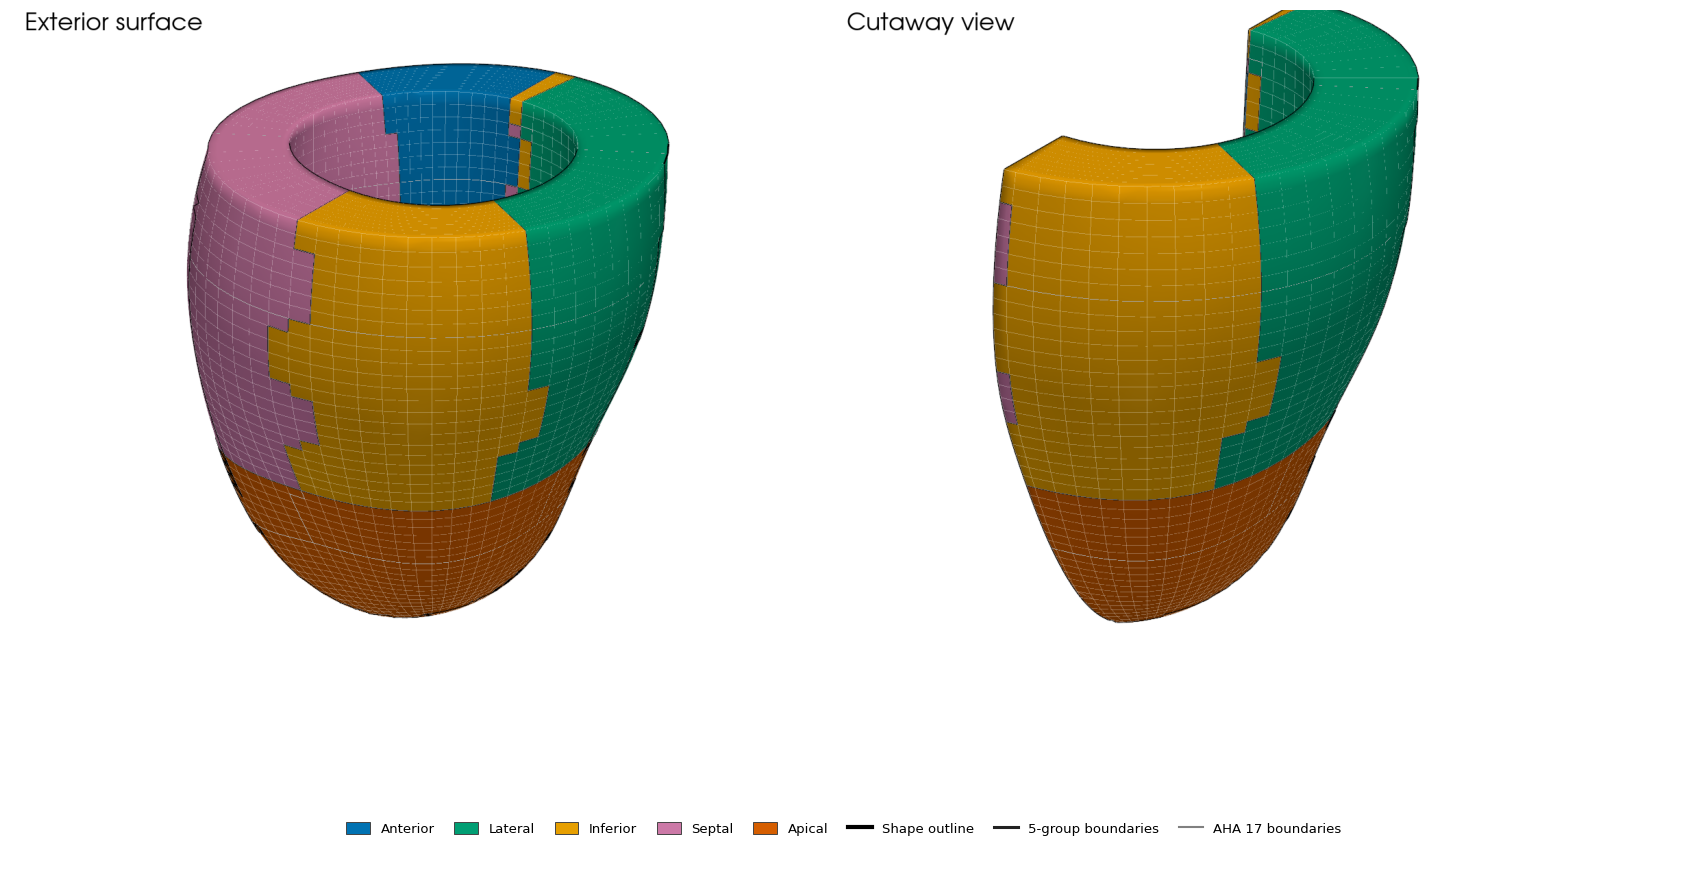

Saved: output_dir\lv_aha5_grouped_surface_cutaway.png


Exception raised
AttributeError("'NoneType' object has no attribute 'GetMouseWheelMotionFactor'")
Traceback (most recent call last):
  File "d:\miniconda3\envs\GPTG\Lib\site-packages\wslink\protocol.py", line 317, in onCompleteMessage
    results = func(*args, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^
  File "d:\miniconda3\envs\GPTG\Lib\site-packages\trame_vtk\modules\vtk\protocols\mouse_handler.py", line 124, in update_zoomFromWheel
    prev_motion_factor = style.GetMouseWheelMotionFactor()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'GetMouseWheelMotionFactor'

Exception raised
AttributeError("'NoneType' object has no attribute 'GetMouseWheelMotionFactor'")
Traceback (most recent call last):
  File "d:\miniconda3\envs\GPTG\Lib\site-packages\wslink\protocol.py", line 317, in onCompleteMessage
    results = func(*args, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^
  File "d:\miniconda3\envs\GPTG\Lib\site-packages\trame

In [ ]:
img_main = render_dual_view(grid, transparent=BG_TRANSPARENT)

nonbg = float((img_main[..., :3].min(axis=-1) < 250).mean())
print(f"Non-background pixel ratio: {nonbg:.3f}")
if nonbg < 0.01:
    print("[WARN] 图像几乎全白，请确认 PyVista 渲染正常。")

compose_figure(img_main, main_fig_path, _draw_aha5_legend,
               transparent=BG_TRANSPARENT)
print(f"Saved: {main_fig_path}")


## Lateral 单图：AHA17 ∈ {5, 6, 11, 12} 四个子段

仅展示 Lateral 组所包含的 4 个子段，内部按子段分色，显示组内结构。


Widget(value='<iframe src="http://localhost:10505/index.html?ui=P_0x248e6713440_0&reconnect=auto" class="pyvis…

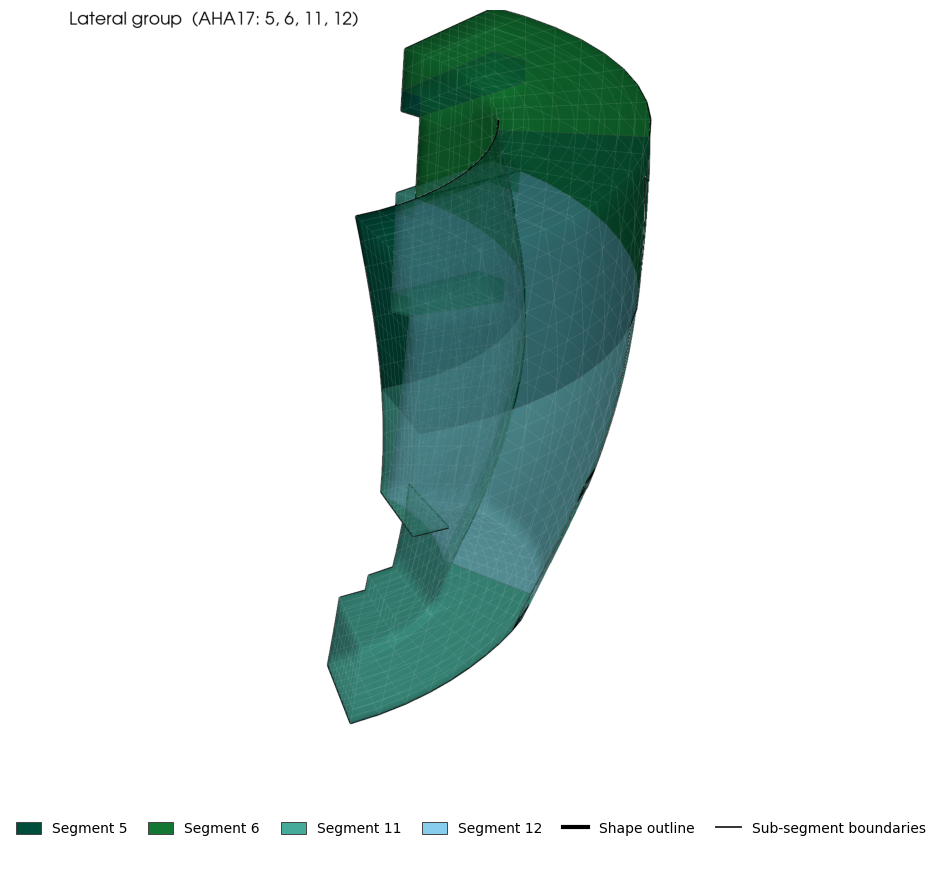

Saved: output_dir\lv_lateral_group_only.png


In [10]:
img_lat = render_lateral_view(grid, transparent=BG_TRANSPARENT)
compose_figure(img_lat, lateral_fig_path, _draw_lateral_legend,
               transparent=BG_TRANSPARENT)
print(f"Saved: {lateral_fig_path}")


## 交互视图（可选）

若已安装 `pyvista[jupyter]`，可在 notebook 内旋转观察。若 `trame` 不可用会自动回退。


In [11]:
show_interactive(grid)


Widget(value='<iframe src="http://localhost:10505/index.html?ui=P_0x2488302d700_0&reconnect=auto" class="pyvis…

## 使用说明

- **配色**：采用 Okabe–Ito / Wong (2011) 色盲安全调色板，与课题组其他 UQ 图保持一致。如需切换为 Tol-muted 或印刷黑白友好版，只需修改 `AHA5_COLORS` 与 `LATERAL_SUB_COLORS`。
- **三层边界**（config 中可独立调节）：
  - `OUTLINE_*`：整体形状外轮廓（最粗，默认黑色 3.0），由 VTK silhouette 实时计算，随视角变化；剖切 cut edges 也会自动纳入。设为 `SHOW_OUTLINE = False` 可关闭。
  - `AHA5_EDGE_*`：5 组之间的分界（中等，默认 2.2）。
  - `AHA17_EDGE_*`：17 段之间的分界（最细，默认 1.0）。
- **主图**：左=整体外表面；右=沿 `CLIP_NORMAL` 剖切。
- **Lateral 单图**：严格按 `AHA17 ∈ {5, 6, 11, 12}` 筛选，不再使用 `AHA5==2` 间接判定；4 个子段分色，配套独立 4 段图例。
- **冲突单元**：在 `load_regions_from_mat` 中被强制归入 segment 17 (Apical cap)。这保证每个单元 label 唯一；但若未来做 **AHA17 粒度的段级分析**，需要注意 segment 17 样本可能被人为膨胀。
- **输出**：`output_dir/` 下 PNG + 可选 VTU。
